Loading test sets from datasets/monash


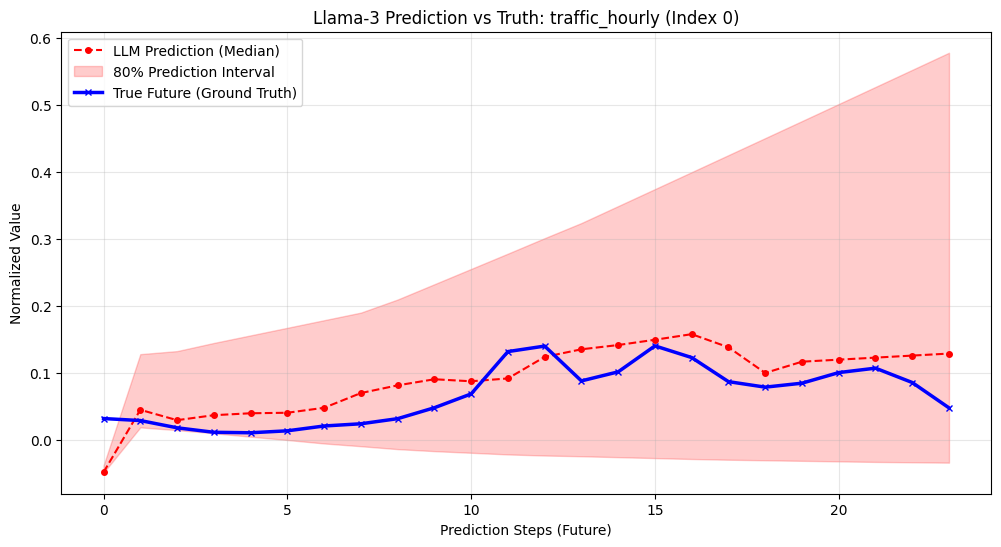

In [16]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
from data.monash import get_datasets

# 1. 데이터 로드 
datasets = get_datasets()
dsname = 'traffic_hourly'
train_list, test_list = datasets[dsname]
train = train_list[:3]
test = test_list[:3]

# 2. 결과 pkl 파일 로드
file_path = 'outputs/monash_mini/traffic_hourly.pkl' 
with open(file_path, 'rb') as f:
    out_dict = pickle.load(f)

# 3. 모델 데이터 추출
model_key = 'ollama/llama3'
actual_data = out_dict[model_key]
preds = actual_data.get('samples')

# --- 시각화 ---
idx = 0 
target_preds = preds[idx]
# 정답 데이터도 예측 길이(len(median_pred))만큼만 앞에서부터 자릅니다.
target_test = test[idx][:len(median_pred)]

median_pred = np.median(target_preds, axis=0)
lower_bound = np.percentile(target_preds, 10, axis=0)
upper_bound = np.percentile(target_preds, 90, axis=0)

plt.figure(figsize=(12, 6))
x_range = np.arange(len(median_pred))

# [빨간 선] LLM의 예측 중앙값
plt.plot(x_range, median_pred, label='LLM Prediction (Median)', color='red', marker='o', markersize=4, linestyle='--')
# [분홍 영역] 80% 신뢰 구간
plt.fill_between(x_range, lower_bound, upper_bound, color='red', alpha=0.2, label='80% Prediction Interval')

# [파란 선] 실제 정답 (True Future) - 이걸 보셔야죠!
plt.plot(x_range, target_test, label='True Future (Ground Truth)', color='blue', linewidth=2.5, marker='x', markersize=5)

plt.title(f"Llama-3 Prediction vs Truth: {dsname} (Index {idx})")
plt.xlabel("Prediction Steps (Future)")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pickle
import matplotlib.pyplot as plt

with open('outputs/monash/traffic_hourly.pkl', 'rb') as f:
    data = pickle.load(f)

# 데이터 구조 확인 (보통 아래 형태)
# data['test_samples']: (20, 24) 형태의 예측값
# data['test_targets']: (24,) 형태의 실제 정답

samples = data['test_samples'][0] # 첫 번째 시계열 샘플
targets = data['test_targets'][0]

plt.figure(figsize=(10, 5))
plt.plot(targets, label='Ground Truth', color='blue')
plt.plot(samples.mean(axis=0), label='LLM Prediction', color='red')
plt.fill_between(range(len(targets)), samples.min(axis=0), samples.max(axis=0), color='red', alpha=0.2)
plt.legend()
plt.show()